In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from xgcm import Grid
import gsw
import warnings
import cartopy.crs as ccrs
import cartopy.feature as cfeature
warnings.filterwarnings('ignore')
import os
import gc
import geopandas

In [3]:
from dask.distributed import Client
client = Client(n_workers=6,
                threads_per_worker=1,
                memory_limit='24GB')
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 6,Total memory: 134.11 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41181,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38931,Total threads: 1
Dashboard: http://127.0.0.1:43219/status,Memory: 22.35 GiB
Nanny: tcp://127.0.0.1:44395,


We first extract one month worth of SOSE data, here March 2013 (it=12), along with the two bounding snapshots.

In [4]:
PATH = "/gws/nopw/j04/coast_hack/SOSE_temp/"
year='2013'
#os.listdir(PATH+year)

In [5]:
it=12

Mass budget terms

In [6]:
ds_VEL_TOT   = xr.open_mfdataset(PATH +f'{year}/*velMass_bsoseI156_{year}_5day.nc')
ds_VEL = ds_VEL_TOT.isel(time=slice(it,it+6))
del(ds_VEL_TOT)

In [7]:
ds_VEL.time

<xarray.DataArray 'time' (time: 6)> Size: 48B
array(['2013-03-06T00:00:00.000000000', '2013-03-11T00:00:00.000000000',
       '2013-03-16T00:00:00.000000000', '2013-03-21T00:00:00.000000000',
       '2013-03-26T00:00:00.000000000', '2013-03-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    iter     (time) int64 48B dask.array<chunksize=(6,), meta=np.ndarray>
  * time     (time) datetime64[ns] 48B 2013-03-06 2013-03-11 ... 2013-03-31
Attributes:
    standard_name:  time
    long_name:      Time
    axis:           T

In [8]:
middle_of_period = xr.DataArray(data = np.array('2013-03-16T00:00:00.000000000', dtype='datetime64[ns]'), 
                               coords = {'time': np.array('2013-03-16T00:00:00.000000000', dtype='datetime64[ns]')})
middle_of_period.attrs["standard_name"] = "time" 
middle_of_period.attrs["long_name"] = "Time" 
middle_of_period.attrs["axis"] = "T" 

In [9]:
ds_VEL=ds_VEL.mean('time')
ds_VEL["time"] = middle_of_period
ds_VEL=ds_VEL.set_coords("time")
ds_VEL=ds_VEL.expand_dims("time")

In [10]:
ds_SSH_TOT   = xr.open_mfdataset(PATH +f'{year}/SSH_bsoseI156_{year}_5day.nc')
ds_SSH = ds_SSH_TOT.isel(time=slice(it,it+6))
ds_SSH = ds_SSH.rename({"ETAN":"SSH"})
del(ds_SSH_TOT)
ds_SSH=ds_SSH.mean('time')
ds_SSH["time"] = middle_of_period
ds_SSH=ds_SSH.set_coords("time")
ds_SSH=ds_SSH.expand_dims("time")

In [16]:
ds_SSH_SNAPS_TOT   = xr.open_mfdataset(PATH +f'{year}/SSH_bsoseI156_{year}_5daySnaps.nc')
ds_SSH_SNAPS = ds_SSH_SNAPS_TOT.isel(time=slice(it,it+7,6))
ds_SSH_SNAPS = ds_SSH_SNAPS.rename({"time":"time_bounds","ETAN":"SSH_bounds"}) # Start renaming diagnostics to match xWMB nomenclature
del(ds_SSH_SNAPS_TOT)

In [17]:
ds_FWFLUX_TOT = xr.open_dataset(PATH + f'{year}/oceFWflx_bsoseI156_{year}_5day.nc')
ds_FWFLUX = ds_FWFLUX_TOT.isel(time=slice(it,it+6))
del(ds_FWFLUX_TOT)
ds_FWFLUX=ds_FWFLUX.mean('time')
ds_FWFLUX["time"] = middle_of_period
ds_FWFLUX=ds_FWFLUX.set_coords("time")
ds_FWFLUX=ds_FWFLUX.expand_dims("time")

Heat budget terms

In [18]:
ds_THETA_TOT = xr.open_dataset(PATH + f'{year}/Theta_bsoseI156_{year}_5day.nc')
ds_THETA = ds_THETA_TOT.isel(time=slice(it,it+6))
del(ds_THETA_TOT)
ds_THETA=ds_THETA.mean('time')
ds_THETA["time"] = middle_of_period
ds_THETA=ds_THETA.set_coords("time")
ds_THETA=ds_THETA.expand_dims("time")

In [19]:
ds_THETA_SNAPS_TOT = xr.open_dataset(PATH + f'{year}/Theta_bsoseI156_{year}_5daySnaps.nc')
ds_THETA_SNAPS = ds_THETA_SNAPS_TOT.isel(time=slice(it,it+7,6))
del(ds_THETA_SNAPS_TOT)
ds_THETA_SNAPS = ds_THETA_SNAPS.rename({"THETA":"THETA_bounds","time":"time_bounds"})

In [20]:
ds_ADV_TH_TOT   = xr.open_mfdataset([PATH +f'{year}/ADVx_TH_bsoseI156_{year}_5day.nc',
                                  PATH +f'{year}/ADVy_TH_bsoseI156_{year}_5day.nc',
                                  PATH +f'{year}/ADVr_TH_bsoseI156_{year}_5day.nc'])
ds_ADV_TH = ds_ADV_TH_TOT.isel(time=slice(it,it+6))
del(ds_ADV_TH_TOT)
ds_ADV_TH=ds_ADV_TH.mean('time')
ds_ADV_TH["time"] = middle_of_period
ds_ADV_TH=ds_ADV_TH.set_coords("time")
ds_ADV_TH=ds_ADV_TH.expand_dims("time")

In [21]:
ds_DIFF_TH_TOT  = xr.open_mfdataset([PATH +f'{year}/DFxE_TH_bsoseI156_{year}_5day.nc',
                                  PATH +f'{year}/DFyE_TH_bsoseI156_{year}_5day.nc',
                                  PATH +f'{year}/DFrI_TH_bsoseI156_{year}_5day.nc'])
ds_DIFF_TH = ds_DIFF_TH_TOT.isel(time=slice(it,it+6))
del(ds_DIFF_TH_TOT)
ds_DIFF_TH=ds_DIFF_TH.mean('time')
ds_DIFF_TH["time"] = middle_of_period
ds_DIFF_TH=ds_DIFF_TH.set_coords("time")
ds_DIFF_TH=ds_DIFF_TH.expand_dims("time")

In [22]:
ds_TFLUX_TOT = xr.open_dataset(PATH + f'{year}/surfTflx_bsoseI156_{year}_5day.nc')
ds_TFLUX = ds_TFLUX_TOT.isel(time=slice(it,it+6))
del(ds_TFLUX_TOT)
ds_TFLUX=ds_TFLUX.mean('time')
ds_TFLUX["time"] = middle_of_period
ds_TFLUX=ds_TFLUX.set_coords("time")
ds_TFLUX=ds_TFLUX.expand_dims("time")

In [23]:
ds_SW_TOT    = xr.open_dataset(PATH + f'{year}/oceQsw_bsoseI156_{year}_5day.nc')
ds_SW = ds_SW_TOT.isel(time=slice(it,it+6))
del(ds_SW_TOT)
ds_SW=ds_SW.mean('time')
ds_SW["time"] = middle_of_period
ds_SW=ds_SW.set_coords("time")
ds_SW=ds_SW.expand_dims("time")

Salt budget terms

In [24]:
ds_SALT_TOT = xr.open_dataset(PATH + f'{year}/Salt_bsoseI156_{year}_5day.nc')
ds_SALT = ds_SALT_TOT.isel(time=slice(it,it+6))
del(ds_SALT_TOT)
ds_SALT=ds_SALT.mean('time')
ds_SALT["time"] = middle_of_period
ds_SALT=ds_SALT.set_coords("time")
ds_SALT=ds_SALT.expand_dims("time")

In [25]:
ds_SALT_SNAPS_TOT = xr.open_dataset(PATH + f'{year}/Salt_bsoseI156_{year}_5daySnaps.nc')
ds_SALT_SNAPS = ds_SALT_SNAPS_TOT.isel(time=slice(it,it+7,6))
del(ds_SALT_SNAPS_TOT)
ds_SALT_SNAPS = ds_SALT_SNAPS.rename({"SALT":"SALT_bounds","time":"time_bounds"})

In [26]:
ds_ADV_SLT_TOT   = xr.open_mfdataset([PATH +f'{year}/ADVx_SLT_bsoseI156_{year}_5day.nc',
                                  PATH +f'{year}/ADVy_SLT_bsoseI156_{year}_5day.nc',
                                  PATH +f'{year}/ADVr_SLT_bsoseI156_{year}_5day.nc'])
ds_ADV_SLT = ds_ADV_SLT_TOT.isel(time=slice(it,it+6))
del(ds_ADV_SLT_TOT)
ds_ADV_SLT=ds_ADV_SLT.mean('time')
ds_ADV_SLT["time"] = middle_of_period
ds_ADV_SLT=ds_ADV_SLT.set_coords("time")
ds_ADV_SLT=ds_ADV_SLT.expand_dims("time")

In [27]:
ds_DIFF_SLT_TOT  = xr.open_mfdataset([PATH +f'{year}/DFxE_SLT_bsoseI156_{year}_5day.nc',
                                  PATH +f'{year}/DFyE_SLT_bsoseI156_{year}_5day.nc',
                                  PATH +f'{year}/DFrI_SLT_bsoseI156_{year}_5day.nc'])
ds_DIFF_SLT = ds_DIFF_SLT_TOT.isel(time=slice(it,it+6))
del(ds_DIFF_SLT_TOT)
ds_DIFF_SLT=ds_DIFF_SLT.mean('time')
ds_DIFF_SLT["time"] = middle_of_period
ds_DIFF_SLT=ds_DIFF_SLT.set_coords("time")
ds_DIFF_SLT=ds_DIFF_SLT.expand_dims("time")

In [28]:
ds_SFLUX_TOT = xr.open_dataset(PATH + f'{year}/surfSflx_bsoseI156_{year}_5day.nc')
ds_SFLUX = ds_SFLUX_TOT.isel(time=slice(it,it+6))
del(ds_SFLUX_TOT)
ds_SFLUX=ds_SFLUX.mean('time')
ds_SFLUX["time"] = middle_of_period
ds_SFLUX=ds_SFLUX.set_coords("time")
ds_SFLUX=ds_SFLUX.expand_dims("time")

In [29]:
ds_MEAN_DATA=xr.merge([ds_VEL, ds_FWFLUX,
                       ds_THETA, ds_ADV_TH , ds_DIFF_TH,  ds_TFLUX, ds_SW,
                       ds_SALT , ds_ADV_SLT, ds_DIFF_SLT,ds_SFLUX],compat="override")

In [30]:
ds_SNAPS_DATA=xr.merge([ds_SSH_SNAPS,ds_THETA_SNAPS,ds_SALT_SNAPS],compat="override")

In [32]:
ds_SNAPS_DATA=ds_SNAPS_DATA.drop_vars("iter")

In [33]:
ds=xr.merge([ds_MEAN_DATA,ds_SNAPS_DATA])

In [34]:
ds['drW'] = ds.hFacW * ds.drF #vertical cell size at u point
ds['drS'] = ds.hFacS * ds.drF #vertical cell size at v point
ds['drC'] = ds.hFacC * ds.drF #vertical cell size at center
ds['depthC'] = ds['drC'].sum('Z') #vertical cell size at center

ds['CV']= ds.rA * ds.drC # Cell volume 
ds['rAW'] = ds.dyG * ds.drW # cell side areas at u location
ds = ds.set_coords( ("drW","drS","drC","CV","rAW") )

In [35]:
ds

<xarray.Dataset> Size: 8GB
Dimensions:       (YC: 588, XG: 2160, Z: 52, time: 1, XC: 2160, YG: 588,
                   Zl: 52, time_bounds: 2)
Coordinates: (12/38)
  * YC            (YC) float32 2kB -77.98 -77.95 -77.91 ... -30.02 -29.87 -29.72
  * XG            (XG) float32 9kB 5.551e-17 0.1667 0.3333 ... 359.5 359.7 359.8
  * Z             (Z) float32 208B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
    dyG           (YC, XG) float32 5MB dask.array<chunksize=(588, 2160), meta=np.ndarray>
    dxC           (YC, XG) float32 5MB dask.array<chunksize=(588, 2160), meta=np.ndarray>
    rAw           (YC, XG) float32 5MB dask.array<chunksize=(588, 2160), meta=np.ndarray>
    ...            ...
  * time_bounds   (time_bounds) datetime64[ns] 16B 2013-03-01 2013-03-31
    drW           (Z, YC, XG) float32 264MB dask.array<chunksize=(52, 588, 2160), meta=np.ndarray>
    drS           (Z, YG, XC) float32 264MB dask.array<chunksize=(52, 588, 2160), meta=np.ndarray>
    drC           (Z, YC, XC) float32 264MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    CV            (YC, XC, Z) float32 264MB dask.array<chunksize=(588, 2160, 52), meta=np.ndarray>
    rAW           (YC, XG, Z) float32 264MB dask.array<chunksize=(588, 2160, 52), meta=np.ndarray>
Data variables: (12/25)
    UVELMASS      (time, Z, YC, XG) float32 264MB dask.array<chunksize=(1, 52, 588, 2160), meta=np.ndarray>
    VVELMASS      (time, Z, YG, XC) float32 264MB dask.array<chunksize=(1, 52, 588, 2160), meta=np.ndarray>
    WVELMASS      (time, Zl, YC, XC) float32 264MB dask.array<chunksize=(1, 52, 588, 2160), meta=np.ndarray>
    oceFWflx      (time, YC, XC) float32 5MB 0.0 0.0 ... -5.144e-05 -5.183e-05
    THETA         (time, Z, YC, XC) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ADVx_TH       (time, Z, YC, XG) float32 264MB dask.array<chunksize=(1, 52, 588, 2160), meta=np.ndarray>
    ...            ...
    DFrI_SLT      (time, Zl, YC, XC) float32 264MB dask.array<chunksize=(1, 52, 588, 2160), meta=np.ndarray>
    SFLUX         (time, YC, XC) float32 5MB 0.0 0.0 0.0 ... 3.179e-06 2.648e-06
    SSH_bounds    (time_bounds, YC, XC) float32 10MB dask.array<chunksize=(2, 588, 2160), meta=np.ndarray>
    THETA_bounds  (time_bounds, Z, YC, XC) float32 528MB ...
    SALT_bounds   (time_bounds, Z, YC, XC) float32 528MB ...
    depthC        (YC, XC) float32 5MB 0.0 0.0 0.0 ... 4.8e+03 4.8e+03 4.737e+03

In [6]:
#ds.to_netcdf("./SOSE_2013-03-16_T000000_30days.nc")
ds = xr.open_dataset("./SOSE_2013-03-16_T000000_30days.nc")

The dataset `ds` contains all diagnostics required to close the mass, heat and salt budgets

In [7]:
# Create xgcm.Grid instance

metrics = {
        ('X',): ['dxC', 'dxG'], # X distances
        ('Y',): ['dyC', 'dyG'], # Y distances
        ('Z',): ['drF','drW', 'drS', 'drC'], # Z distances
        ('X', 'Y'): ['rA', 'rAs', 'rAw'] # Areas
    }

coords={'X': {'center': 'XC', 'left': 'XG'},
        'Y': {'center': 'YC', 'left': 'YG'},
        'Z': {'center': 'Z', 'left': 'Zl'},
        'T': {'center': 'time', 'outer': 'time_bounds'}}

grid = Grid(ds,  periodic=['X'], coords=coords, metrics = metrics, boundary={'X':'periodic','Y':'extend','Z':'fill','T':'extend'}, fill_value=0)
grid

<xgcm.Grid>
X Axis (periodic, boundary='periodic'):
  * center   XC --> left
  * left     XG --> center
Y Axis (not periodic, boundary='extend'):
  * center   YC --> left
  * left     YG --> center
Z Axis (not periodic, boundary='fill'):
  * center   Z --> left
  * left     Zl --> center
T Axis (not periodic, boundary='extend'):
  * center   time --> outer
  * outer    time_bounds --> center

In [8]:
rho_0 = 1035.     # kg/m3
Cp = 3994.        # J/kg/K
g_to_kg = 0.001  
day_per_second = 1/86400.

In [9]:
mask2D = (1.-ds.maskInC).isel(YC=slice(0,587))
land = (mask2D == 1).isel(YC=slice(0,587))
maskZ = xr.DataArray(np.zeros(len(ds['Z'])),dims=['Z'],coords={'Z':ds['Z']})
maskZ[0] = 1 

### Mass budget ###

The computation is Boussinesq, and z* stretching takes into account the evolution of the free surface:
$$ 
\int_{-H}^{\eta} \nabla \cdot \vec{u} \mathrm{d} z = \frac{\partial \eta}{\partial t}
$$
Integrating over the horizontal area of the water column, and discretizing in the vertical direction $k$, we obtain:
$$ 
\sum_k \left(\iiint \nabla \cdot \vec{u}\mathrm{d} V \right)_{ijk} = \iint_{S_{xy}} \frac{\partial \eta}{\partial t} \mathrm{d} S = A_{xy} \frac{\partial \eta}{\partial t},
$$
where $A_{xy}$ is the area of the water column.
Thus, the divergence integrated over the volume of a single cell can be computed as:
$$
\left(\iiint \nabla \cdot \vec{u}\mathrm{d} V \right)_{ijk} = \left( A_{xy} \frac{\partial \eta}{\partial t}  \right) \times \frac{dz_k}{H}
$$
The divergence integrated over the volume of a single cell is also given, applying Stokes theorem, by:
$$
\left(\iiint \nabla \cdot \vec{u}\mathrm{d} V \right)_{ijk} = (dSx_{i+1}U_{i+1} - dSx_i U_i) + (dSy_{j+1}V_{j+1} - dSy_j V_j) + (dSz_{k+1}W_{k+1} - dSz_k W_k ) 
$$
i, j, k are the zonal, meridional and vertical indices, respectively. \
U, V, W are the zonal, meridional and vertical velocity fields, respectively. \
dSx, dSy, dSz are the associated cell areas.

Combining these last two equations and multiplying them by $\rho_0$, we obtain our cell-by-cell mass budget:
$$
\rho_0 \left( \left( A_{xy} \frac{\partial \eta}{\partial t}\right) \times \frac{dz_k}{H} \right) = \rho_0 \left( (dSx_{i+1}U_{i+1} - dSx_i U_i) + (dSy_{j+1}V_{j+1} - dSy_j V_j) + (dSz_{k+1}W_{k+1} - dSz_k W_k ) \right) 
$$

In [10]:
# Compute the mass transports
grid._ds["UMASSTRANS"] = ds["UVELMASS"] * ds.dyG * ds.drF * rho_0
grid._ds["VMASSTRANS"] = ds["VVELMASS"] * ds.dxG * ds.drF * rho_0
grid._ds["WMASSTRANS"] = ds["WVELMASS"] * ds.rA * rho_0

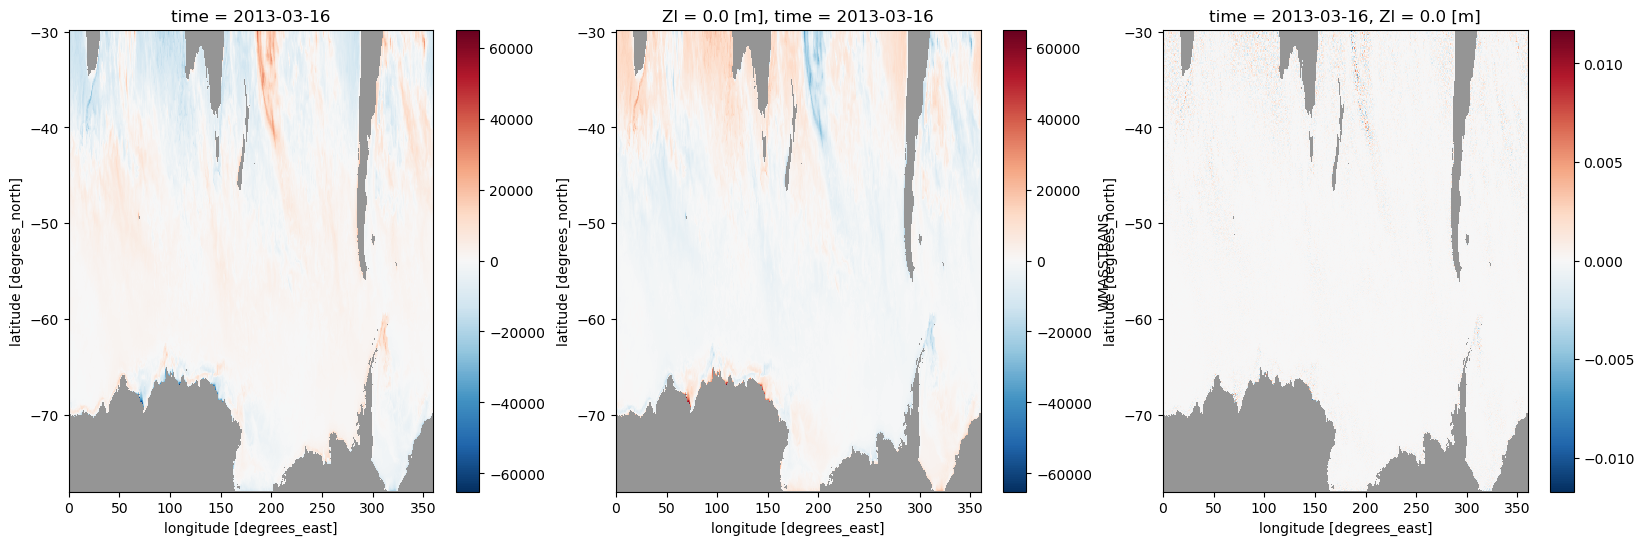

In [11]:
# Show that the vertical mass transport at the surface is equal to (minus) the net fresh water flux at the surface
# the difference is about 7 orders of magnitude less than the terms, which is expected with single precision output
fig,axs=plt.subplots(1,3,figsize=(20,6))

land.plot(ax=axs[0], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
(ds["oceFWflx"].isel(time=0)*ds.rA).where(mask2D == 0).plot(ax=axs[0])
land.plot(ax=axs[1], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
(ds['WMASSTRANS'].isel(time=0,Zl=0)).where(mask2D == 0).plot(ax=axs[1])
land.plot(ax=axs[2], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
(ds["oceFWflx"].isel(time=0)*ds.rA + ds['WMASSTRANS'].isel(time=0,Zl=0)).where(mask2D == 0).plot(ax=axs[2]);

In [12]:
# Compute zonal divergence of zonal transport
ds["DELTA_UMASSTRANS"]=grid.diff(ds['UMASSTRANS'],'X') 
ds["DELTA_UMASSTRANS"].compute();

In [13]:
# Compute meridional divergence of meridional transport
ds["DELTA_VMASSTRANS"]=grid.diff(ds['VMASSTRANS'],'Y',boundary = 'extend') 
ds["DELTA_VMASSTRANS"].compute();

In [14]:
# Setting sea surface vertical velocity to zero to avoid double counting with the fresh water flux
ds["WMASSTRANS"][dict(time=0, Zl=0)] = 0.0

In [15]:
# Compute vertical divergence of vertical transport
ds["DELTA_WMASSTRANS"]=grid.diff(ds['WMASSTRANS'],'Z',boundary = 'fill', fill_value = 0)
ds["DELTA_WMASSTRANS"].compute();

In [16]:
# Sum to obtain divergence
DIV = - ds["DELTA_UMASSTRANS"] - ds["DELTA_VMASSTRANS"] + ds["DELTA_WMASSTRANS"]

In [17]:
delta_t=(((ds.time_bounds[1]-ds.time_bounds[0]))/np.timedelta64(1, 's')).values

In [18]:
delta_t

array(2592000.)

In [20]:
# Here, compute the thickness tendency due to Z* stretching accounting for SSH tendency 
WEIGHTS = grid._ds["drC"]/grid._ds["depthC"]        # dz(k)/H
SSH_TEND = grid.diff(ds['SSH_bounds'],'T')/delta_t  # d(eta)/dt
ds["SSH_TEND_3D"] = SSH_TEND*WEIGHTS

In [21]:
ds

<xarray.Dataset> Size: 10GB
Dimensions:           (YC: 588, XG: 2160, Z: 52, time: 1, XC: 2160, YG: 588,
                       Zl: 52, time_bounds: 2)
Coordinates: (12/38)
  * YC                (YC) float32 2kB -77.98 -77.95 -77.91 ... -29.87 -29.72
  * XG                (XG) float32 9kB 5.551e-17 0.1667 0.3333 ... 359.7 359.8
  * Z                 (Z) float32 208B -2.1 -6.7 -12.15 ... -5.4e+03 -5.8e+03
    dyG               (YC, XG) float32 5MB ...
    dxC               (YC, XG) float32 5MB ...
    rAw               (YC, XG) float32 5MB ...
    ...                ...
  * time_bounds       (time_bounds) datetime64[ns] 16B 2013-03-01 2013-03-31
    drW               (Z, YC, XG) float32 264MB ...
    drS               (Z, YG, XC) float32 264MB ...
    drC               (Z, YC, XC) float32 264MB ...
    CV                (YC, XC, Z) float32 264MB ...
    rAW               (YC, XG, Z) float32 264MB ...
Data variables: (12/32)
    UVELMASS          (time, Z, YC, XG) float32 264MB ...
    VVELMASS          (time, Z, YG, XC) float32 264MB ...
    WVELMASS          (time, Zl, YC, XC) float32 264MB ...
    oceFWflx          (time, YC, XC) float32 5MB ...
    THETA             (time, Z, YC, XC) float32 264MB ...
    ADVx_TH           (time, Z, YC, XG) float32 264MB ...
    ...                ...
    VMASSTRANS        (time, Z, YG, XC) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0
    WMASSTRANS        (time, Zl, YC, XC) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0
    DELTA_UMASSTRANS  (time, Z, YC, XC) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0
    DELTA_VMASSTRANS  (time, Z, YC, XC) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0
    DELTA_WMASSTRANS  (time, Z, YC, XC) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0
    SSH_TEND_3D       (time, YC, XC, Z) float64 528MB nan nan nan ... 0.0 0.0

In [21]:
# Vertically sum these terms
DIV_2D = DIV.sum('Z')
DELTA_UMASSTRANS_2D = ds.DELTA_UMASSTRANS.sum('Z')
DELTA_VMASSTRANS_2D = ds.DELTA_VMASSTRANS.sum('Z')
DELTA_WMASSTRANS_2D = ds.DELTA_WMASSTRANS.sum('Z')

In [22]:
ZSTARSTRETCH_MASS = rho_0 * ds.rA * ds.SSH_TEND_3D

In [23]:
LHS = ZSTARSTRETCH_MASS

In [24]:
RHS = DIV + ds["oceFWflx"]*ds.rA*maskZ

In [25]:
RES = LHS - RHS

In [26]:
RES2D = RES.sum('Z')

In [27]:
DIV_2D = DIV_2D.rename("DIV")
RES2D = RES2D.rename("RES")

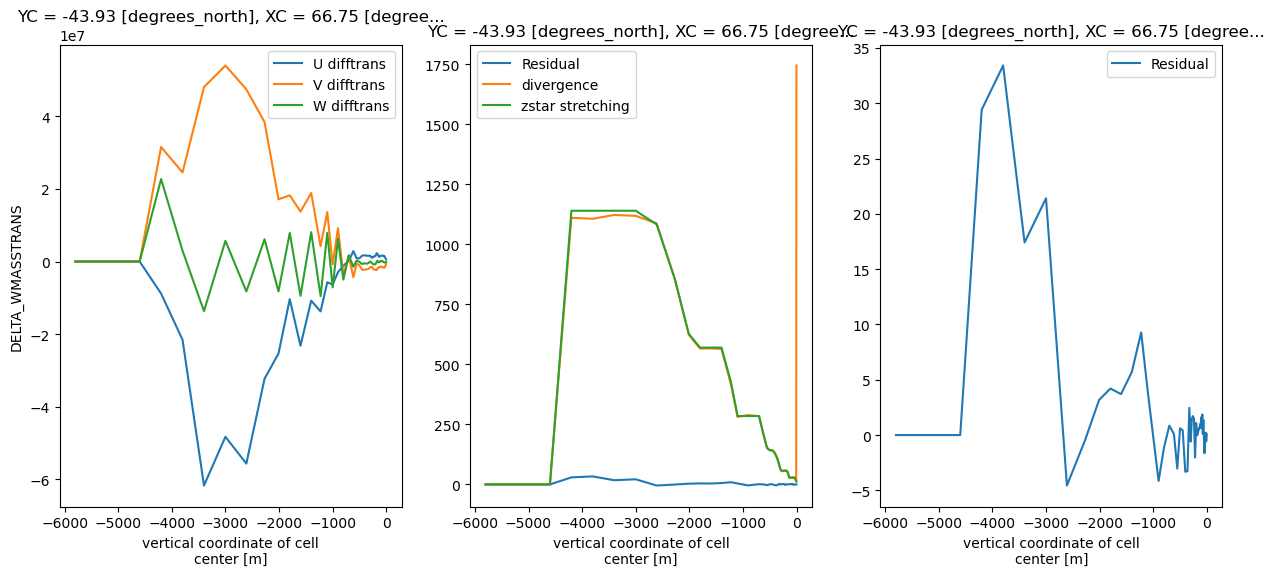

In [28]:
# Example vertical profile of the mass budget
ix=400
iy=480
fig,axs=plt.subplots(1,3,figsize=(15,6))

ds.DELTA_UMASSTRANS.isel(time=0,XC=ix,YC=iy).plot(ax=axs[0],label='U difftrans')
ds.DELTA_VMASSTRANS.isel(time=0,XC=ix,YC=iy).plot(ax=axs[0],label='V difftrans')
ds.DELTA_WMASSTRANS.isel(time=0,XC=ix,YC=iy).plot(ax=axs[0],label='W difftrans') 
RES.isel(time=0,XC=ix,YC=iy).plot(ax=axs[1],label='Residual')
DIV.isel(time=0,XC=ix,YC=iy).plot(ax=axs[1],label='divergence')
ZSTARSTRETCH_MASS.isel(time=0,XC=ix,YC=iy).plot(ax=axs[1],label='zstar stretching')
RES.isel(time=0,XC=ix,YC=iy).plot(ax=axs[2],label='Residual')
axs[0].legend();
axs[1].legend();
axs[2].legend();

The budget is closed down to machine precision, since we have about 7 orders of magnitude of difference between the dominating terms and the residual. 

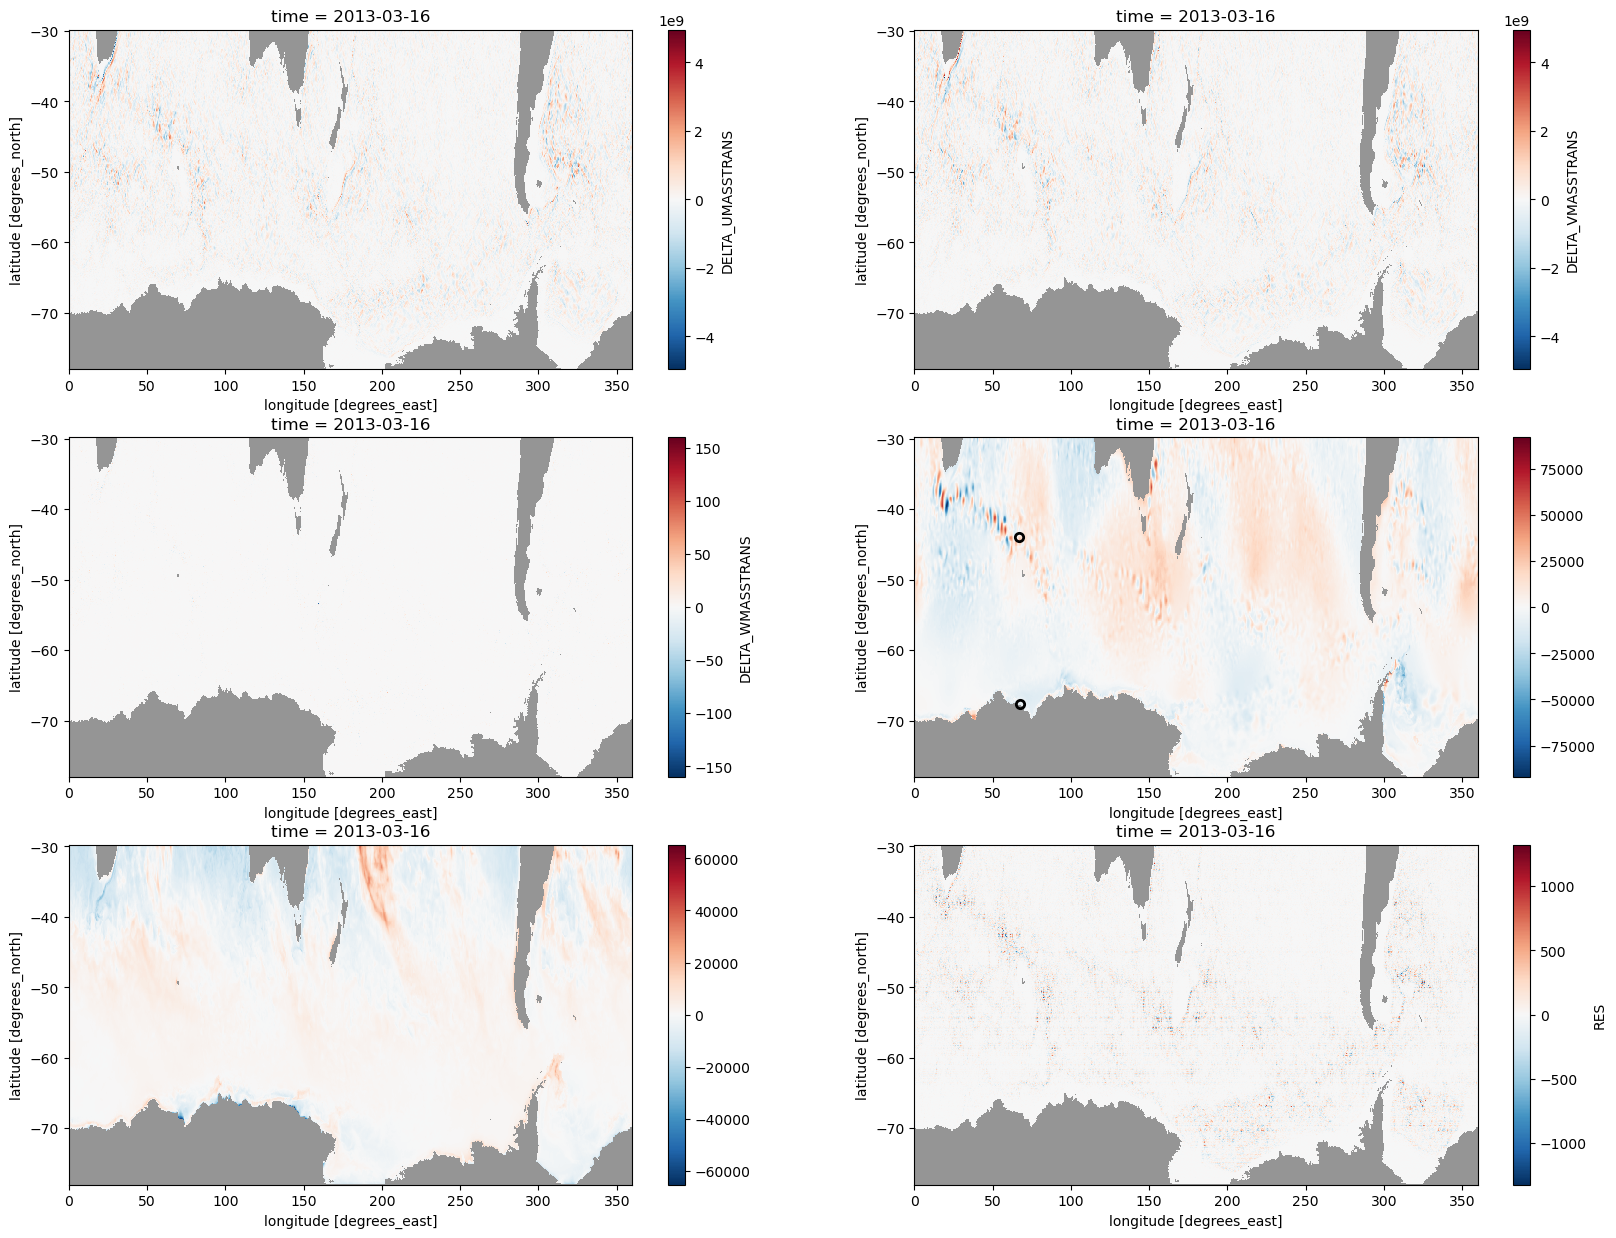

In [29]:
# plot vertically integrated terms

fig,axs=plt.subplots(3,2,figsize=(20,15))

land.plot(ax=axs[0,0], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
DELTA_UMASSTRANS_2D.isel(time=0,YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[0,0])

land.plot(ax=axs[0,1], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
DELTA_VMASSTRANS_2D.isel(time=0,YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[0,1])

land.plot(ax=axs[1,0], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
DELTA_WMASSTRANS_2D.isel(time=0,YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[1,0])

land.plot(ax=axs[1,1], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
(ZSTARSTRETCH_MASS.sum('Z')).isel(time=0,YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[1,1])

land.plot(ax=axs[2,0], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
(ds["oceFWflx"]*ds.rA).isel(time=0,YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[2,0])

land.plot(ax=axs[2,1], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
RES2D.isel(time=0,YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[2,1])

# location of the vertical profiles on the DIV plot
axs[1,1].plot(67.42,-67.61,'o',markeredgewidth=2,markeredgecolor='black',markerfacecolor='None' )
axs[1,1].plot(66.75,-43.93,'o',markeredgewidth=2,markeredgecolor='black',markerfacecolor='None' );

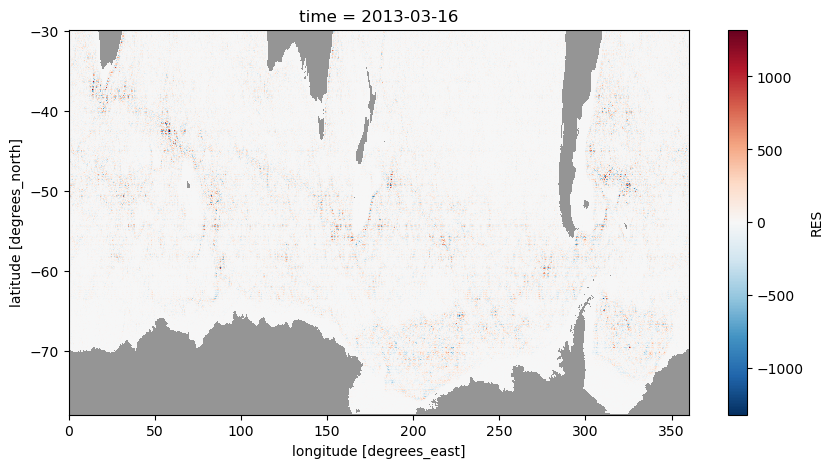

In [30]:
fig,axs=plt.subplots(1,1,figsize=(10,5))
land.plot(ax=axs, cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
RES2D.isel(time=0,YC=slice(0,587)).where(mask2D == 0).plot(ax=axs)

Higher values of the residual are found in regions of high activity, but still remain low enough

In [31]:
ds=ds.drop_vars(["WMASSTRANS","DELTA_UMASSTRANS","DELTA_VMASSTRANS"])

In [32]:
del(LHS,RHS,DELTA_UMASSTRANS_2D,DELTA_VMASSTRANS_2D,DELTA_WMASSTRANS_2D,
    DIV, DIV_2D,RES,RES2D,WEIGHTS,ZSTARSTRETCH_MASS)

### Heat budget ###

The heat budget should be:
$$
\frac{d ( \text{Heat content})}{d t} = \text{ADVECTION} + \text{DIFFUSION} + \text{SHORT WAVE HEATING} + \text{SURFACE NON SW HEATING}
$$

To account for Z* stretching, we compute the Eulerian tendency of heat by taking the Z* corrected temperature tendency:
$$
\frac{d ( \text{Heat content})}{d t} = C_p \rho_0 V_{\text{cell}} \frac{ d \left[(1+\eta/H) \theta \right]}{d t}
$$
With $\theta$ the potential temperature, $C_p = 3992 J/kg/C$ the specific heat capacity of sea water. 

Note that some of the outputted diagnostics indicate temperature tendencies (tracer concentration tendencies). We want to close the budget for tracer content (total cell heat content), thus we multiply ADV and DIFF by $\rho_0 \times C_p$ and the Eulerian temperature tendency by $\text{VOLUME} \times \rho_0 \times C_p$

We compute these terms in the following.

In [33]:
ds["sTHETA"] = ds.THETA_bounds*(1+ds.SSH_bounds/ds.depthC)
ds["TEMP_TEND"] = grid.diff(ds['sTHETA'],'T') / delta_t
HEAT_TEND =  ds.TEMP_TEND * ds.rA * ds.drC * rho_0 * Cp
HEAT_TEND = HEAT_TEND.rename('HEAT_TEND')

In [34]:
ds["DELTA_ADVx_TH"] = grid.diff(ds['ADVx_TH'],'X')
ds["DELTA_ADVy_TH"] = grid.diff(ds['ADVy_TH'],'Y',boundary = 'extend')
ds["DELTA_ADVr_TH"] = grid.diff(ds['ADVr_TH'],'Z',boundary = 'fill', fill_value = 0)

In [35]:
ADV_HEAT = (ds["DELTA_ADVx_TH"] + ds["DELTA_ADVy_TH"] - ds["DELTA_ADVr_TH"]) * rho_0 * Cp
ADV_HEAT = ADV_HEAT.rename('ADV_HEAT')

In [36]:
ds["DELTA_DFxE_TH"] = grid.diff(ds['DFxE_TH'],'X')  
ds["DELTA_DFyE_TH"] = grid.diff(ds['DFyE_TH'],'Y',boundary = 'extend') 
ds["DELTA_DFrI_TH"] = grid.diff(ds['DFrI_TH'],'Z',boundary = 'fill', fill_value = 0)

In [37]:
DF_HEAT = (-ds["DELTA_DFxE_TH"] - ds["DELTA_DFyE_TH"] + ds["DELTA_DFrI_TH"]) * rho_0 * Cp
DF_HEAT = DF_HEAT.rename('DF_HEAT')

In [38]:
# The short wave heating term demands a bit of work

Zlp1 = np.concatenate([ds.Zl.values,[-6000.]])
q1 = 0.62 * np.exp(Zlp1[:-1]/0.6) + (1-0.62) * np.exp(Zlp1[:-1]/20.0) 
q2 = 0.62 * np.exp(Zlp1[1:]/0.6) + (1-0.62) * np.exp(Zlp1[1:]/20.0)

# Correction for the 200m cutoff
zCut = np.where(ds.Z < -200)[0][0]
q1[zCut:] = 0
q2[zCut-1:] = 0
# Create xarray data arrays
q1 = xr.DataArray(q1,coords=[ds.Z],dims=['Z'])
q2 = xr.DataArray(q2,coords=[ds.Z],dims=['Z'])
landmask = ds.hFacC.copy(deep=True).compute()
landmask.values[landmask.values > 0] = 1
ds["TFLUXmSW"] = (ds['TFLUX'] - (1-q1[0]+q2[0])*ds['oceQsw']) * landmask.isel(Z=0)
SF = ds["TFLUXmSW"] * ds.rA
## Calculate subsurface shortwave radiation penetration 
SBSFQSW = ((q1 * (landmask == 1)-q2*(landmask.shift(Z=-1)==1))*ds['oceQsw']).rename('QSW')
SBSFQSW.values[SBSFQSW.Z == -2.1] = 0 
ds["SBSFQSW"] = SBSFQSW
SBSFQSW = ds["SBSFQSW"] * ds.rA

In [39]:
LHS = HEAT_TEND + ADV_HEAT

In [40]:
RHS = DF_HEAT + SF*maskZ + SBSFQSW

In [41]:
# Here compute the heat budget first with, then without the divergence term

RES = LHS - RHS

In [42]:
RES2D = RES.sum('Z')
HEAT_TEND2D = HEAT_TEND.sum('Z')
ADV_HEAT2D = ADV_HEAT.sum('Z')
SBSFQSW2D = SBSFQSW.sum('Z')
DF_HEAT2D = DF_HEAT.sum('Z')

In [43]:
SBSFQSW2D = SBSFQSW2D.rename("Short wave")
SF = SF.rename("non-SW heat flux")
RES2D = RES2D.rename("Residual")

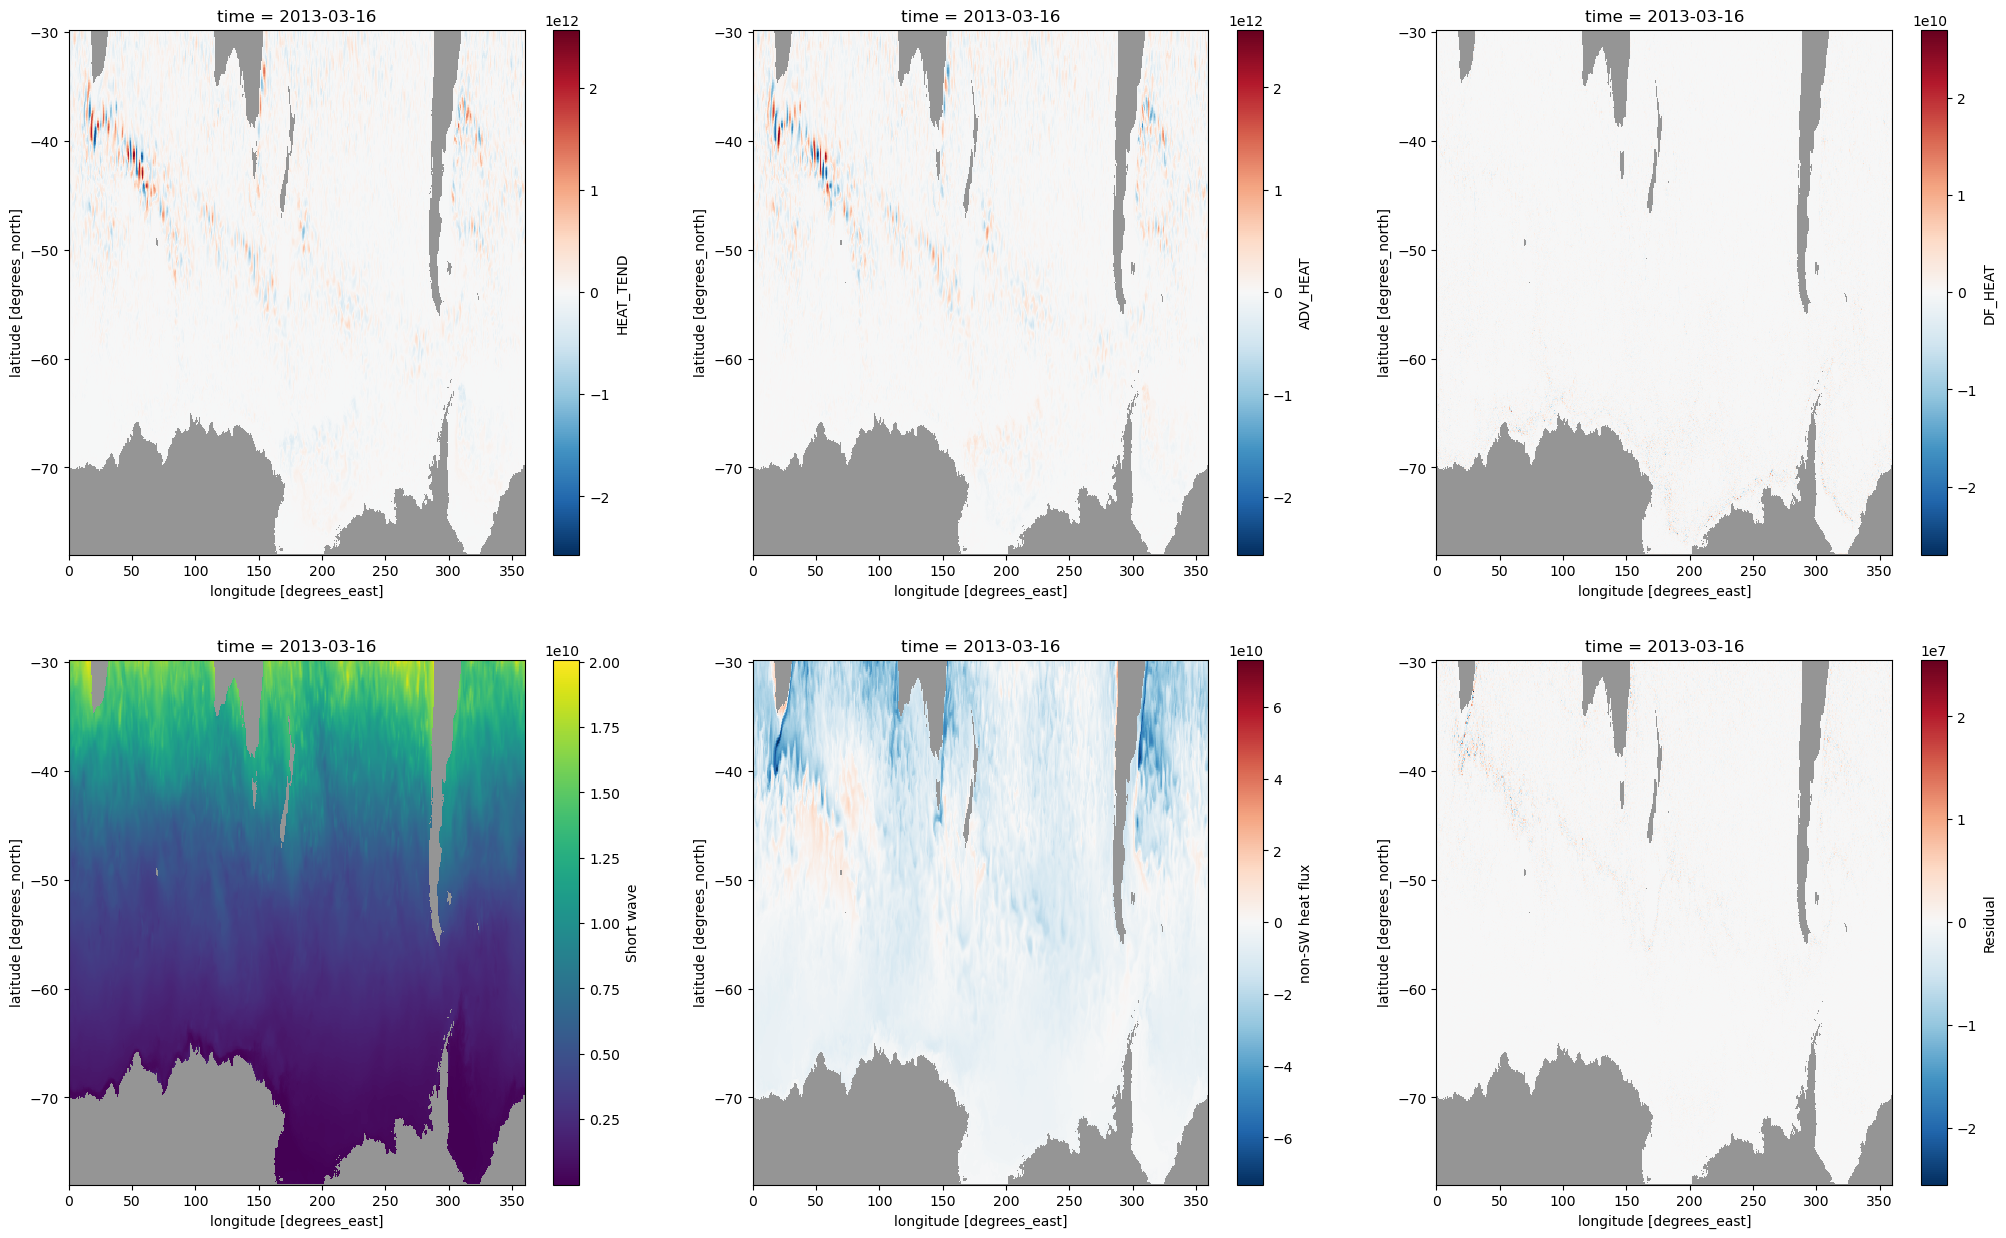

In [44]:
fig,axs=plt.subplots(2,3,figsize=(25,15))

land.plot(ax=axs[0,0], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
HEAT_TEND2D.isel(time=0,YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[0,0])
land.plot(ax=axs[0,1], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
ADV_HEAT2D.isel(time=0,YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[0,1])
land.plot(ax=axs[0,2], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
DF_HEAT2D.isel(time=0,YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[0,2])
land.plot(ax=axs[1,0], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
SBSFQSW2D.isel(time=0,YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[1,0])
land.plot(ax=axs[1,1], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
SF.isel(time=0,YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[1,1])
land.plot(ax=axs[1,2], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
RES2D.isel(time=0,YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[1,2]);


Here the vertical sum of the residual is 5 orders magnitude smaller than the dominant terms, which indicates good closure.

In [45]:
ds=ds.drop_vars(["ADVx_TH","ADVy_TH","ADVr_TH",
                 "DFxE_TH","DFyE_TH","DFrI_TH",
                 "TFLUX","oceQsw"])

In [46]:
del(ADV_HEAT,ADV_HEAT2D,
    DF_HEAT,DF_HEAT2D,
    HEAT_TEND,HEAT_TEND2D,
    LHS,RHS,RES,RES2D,
    SBSFQSW,SBSFQSW2D,SF,SSH_TEND )

### Salt budget ###

Taking into account the "salt divergence term", the salt budget should be:
$$
\frac{d ( \text{Salt content})}{d t} = \text{ADVECTION} + \text{DIFFUSION} + \text{SURFACE SALT FLUX} + \text{DIV}_{\text{Salt}}
$$
To account for Z* stretching, we compute the Eulerian tendency of salt by taking the Z* corrected salinity tendency:
$$
\frac{d ( \text{Salt content})}{d t} = 0.001 \rho_0 V_{\text{cell}} \frac{ d \left[(1+\eta/H) S \right]}{d t}
$$
With $S$ the salinity, the 0.001 multiplication converting from grams of salt to kilograms of salt.  

Again, we want the budgets to be made in tracer content (salt) and not in tracer concentration (salinity).

We compute these terms in the following.

In [47]:
ds["sSALIN"] = ds.SALT_bounds*(1+ds.SSH_bounds/ds.depthC)
ds["SALIN_TEND"] = grid.diff(ds['sSALIN'],'T') / delta_t
SALT_TEND =  ds.SALIN_TEND * rho_0 * ds.rA * ds.drC * g_to_kg
SALT_TEND = SALT_TEND.rename('SALT_TEND')

In [48]:
ds["DELTA_ADVx_SLT"] = grid.diff(ds['ADVx_SLT'],'X')
ds["DELTA_ADVy_SLT"] = grid.diff(ds['ADVy_SLT'],'Y',boundary = 'extend')
ds["DELTA_ADVr_SLT"] = grid.diff(ds['ADVr_SLT'],'Z',boundary = 'fill', fill_value = 0)

In [49]:
ADV_SALT = (ds["DELTA_ADVx_SLT"] + ds["DELTA_ADVy_SLT"] - ds["DELTA_ADVr_SLT"]) * rho_0 * g_to_kg
ADV_SALT = ADV_SALT.rename('ADV_SALT')

In [50]:
ds["DELTA_DFxE_SLT"] = grid.diff(ds['DFxE_SLT'],'X')  
ds["DELTA_DFyE_SLT"] = grid.diff(ds['DFyE_SLT'],'Y',boundary = 'extend') 
ds["DELTA_DFrI_SLT"] = grid.diff(ds['DFrI_SLT'],'Z',boundary = 'fill', fill_value = 0)

In [51]:
DF_SALT = (- ds["DELTA_DFxE_SLT"] - ds["DELTA_DFyE_SLT"] + ds["DELTA_DFrI_SLT"]) * rho_0 * g_to_kg
DF_SALT = DF_SALT.rename('DF_SALT')

In [52]:
SALTFLX = ds["SFLUX"] * ds.rA * g_to_kg * maskZ

In [53]:
LHS = SALT_TEND + ADV_SALT

In [54]:
RHS = DF_SALT + SALTFLX

In [55]:
RES =  LHS - RHS

In [56]:
RES2D = RES.sum('Z')
SALT_TEND2D = SALT_TEND.sum('Z')
ADV_SLT2D = ADV_SALT.sum('Z')
SALTFLX2D = SALTFLX.sum('Z')
DIFF_SLT2D = DF_SALT.sum('Z')


In [57]:
SALTFLX2D = SALTFLX2D.rename("Salt surf flux")
RES2D = RES2D.rename("Residual")

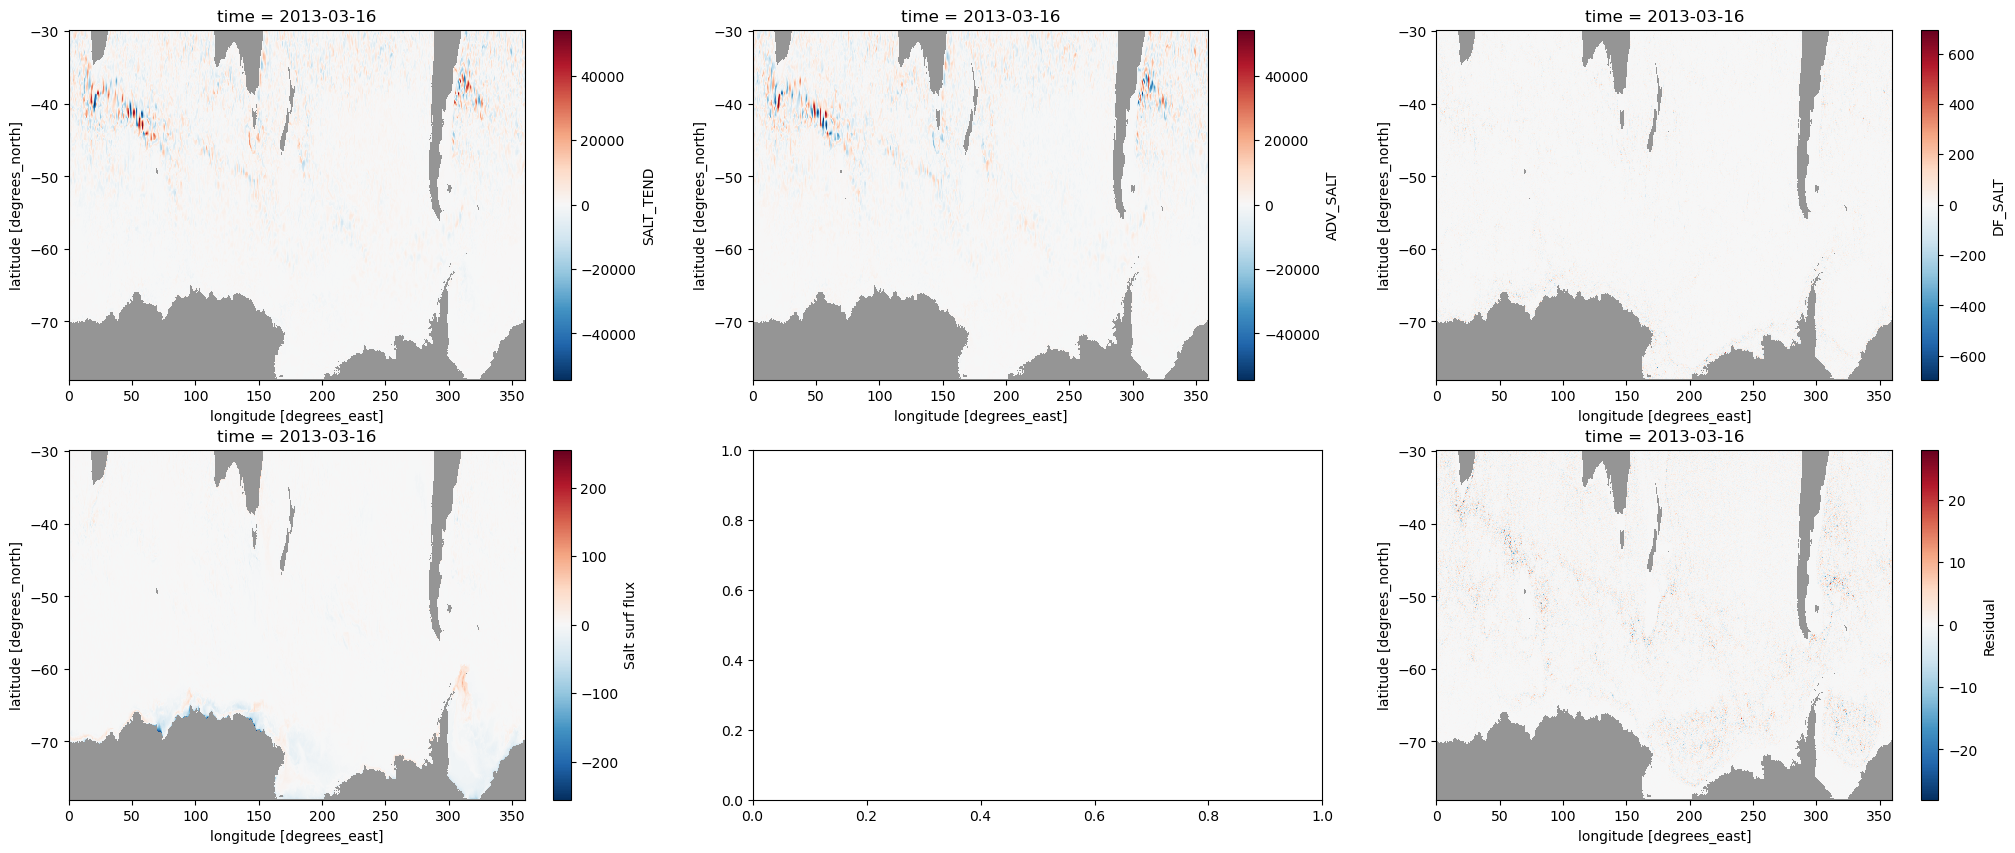

In [58]:
fig,axs=plt.subplots(2,3,figsize=(25,10))
land.plot(ax=axs[0,0], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
SALT_TEND2D.isel(YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[0,0])
land.plot(ax=axs[0,1], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
ADV_SLT2D.isel(YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[0,1])
land.plot(ax=axs[0,2], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
DIFF_SLT2D.isel(YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[0,2])
land.plot(ax=axs[1,0], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
SALTFLX2D.isel(YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[1,0])
land.plot(ax=axs[1,2], cmap="Greys", vmin=0.5, vmax=1.5, add_colorbar=False)
RES2D.isel(YC=slice(0,587)).where(mask2D == 0).plot(ax=axs[1,2]);


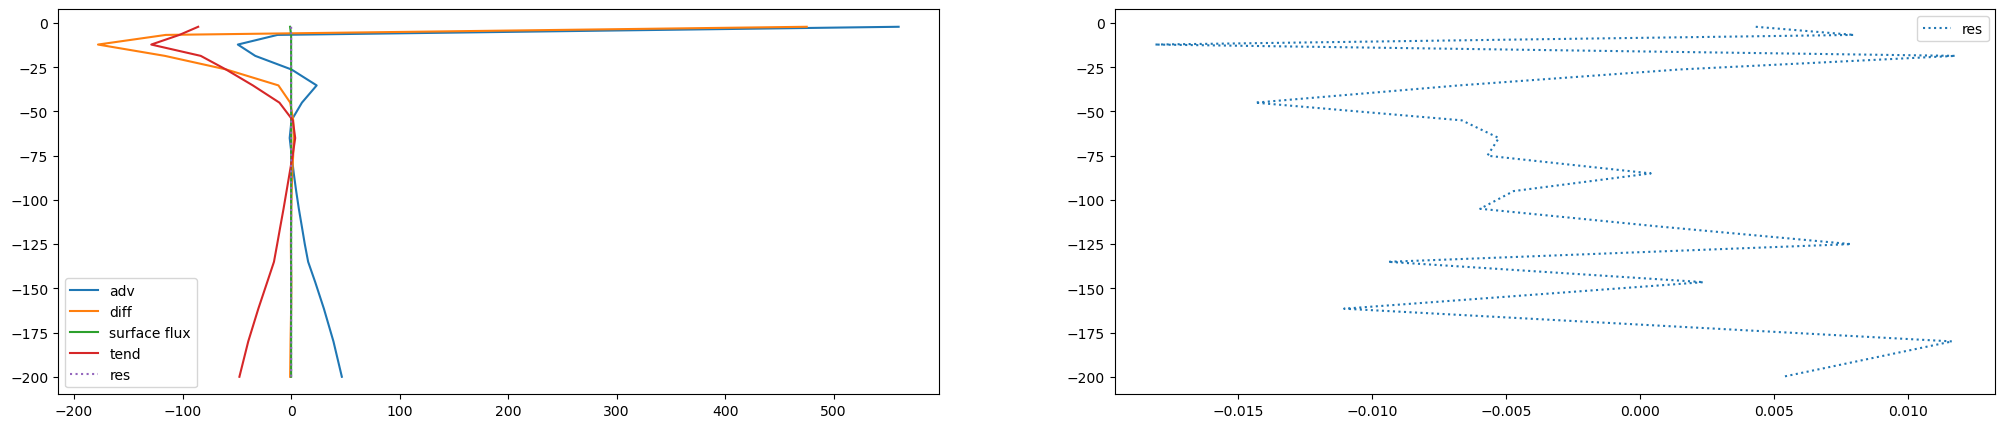

In [59]:
# Salt budget example vertical profile
# Here the salt divergence term is quite negligible

iy = 580
ix = 1200
fig, axs = plt.subplots(1,2,figsize=(25,5))
axs[0].plot(ADV_SALT.isel(time=0,XC=ix, YC=iy)[:20],ds.Z[:20],label = 'adv')
axs[0].plot(DF_SALT.isel(time=0,XC=ix, YC=iy)[:20],ds.Z[:20],label = 'diff')
axs[0].plot(SALTFLX.isel(time=0,XC=ix, YC=iy)[:20],ds.Z[:20],label = 'surface flux')
#axs[0].plot(DIV_SALT.isel(XC=ix, YC=iy)[:20],ds.Z[:20],label = 'DIV_SALT')
axs[0].plot(SALT_TEND.isel(time=0,XC=ix, YC=iy)[:20],ds.Z[:20],label = 'tend')
axs[0].plot(RES.isel(time=0,XC=ix, YC=iy,Z=slice(20)),ds.Z[:20],label = 'res',linestyle = ':')
axs[1].plot(RES.isel(time=0,XC=ix, YC=iy,Z=slice(20)),ds.Z[:20],label = 'res',linestyle = ':')
axs[0].legend()
axs[1].legend()
plt.show()

In [60]:
ds=ds.drop_vars(["ADVx_SLT","ADVy_SLT","ADVr_SLT",
                 "DFxE_SLT","DFyE_SLT","DFrI_SLT"])

In [61]:
del(ADV_SALT,ADV_SLT2D,
    DF_SALT,DIFF_SLT2D,
    SALT_TEND,SALT_TEND2D,
    LHS,RHS,RES,RES2D,
    SALTFLX ,SALTFLX2D)

At this point, we have closed the mass, heat and salt budgets in SOSE.
In the following, we rename, and group diagnostics together to reduce the size of the dataset needed for a xWMB application. 

In [62]:
ds["sigma2"] = gsw.density.sigma2(ds["SALT"], ds["THETA"])

In [63]:
ds["sigma2_bounds"] = gsw.density.sigma2(ds["SALT_bounds"], ds["THETA_bounds"])

In [64]:
ds=ds.drop_vars(["sTHETA","sSALIN"])

In [65]:
ds["mask2D"] = (1.-ds.maskInC)
ds["land"] = (ds.mask2D == 1)

In [66]:
ds

<xarray.Dataset> Size: 12GB
Dimensions:           (YC: 588, XG: 2160, Z: 52, time: 1, XC: 2160, YG: 588,
                       Zl: 52, time_bounds: 2)
Coordinates: (12/38)
  * YC                (YC) float32 2kB -77.98 -77.95 -77.91 ... -29.87 -29.72
  * XG                (XG) float32 9kB 5.551e-17 0.1667 0.3333 ... 359.7 359.8
  * Z                 (Z) float32 208B -2.1 -6.7 -12.15 ... -5.4e+03 -5.8e+03
    dyG               (YC, XG) float32 5MB ...
    dxC               (YC, XG) float32 5MB ...
    rAw               (YC, XG) float32 5MB ...
    ...                ...
  * time_bounds       (time_bounds) datetime64[ns] 16B 2013-03-01 2013-03-31
    drW               (Z, YC, XG) float32 264MB ...
    drS               (Z, YG, XC) float32 264MB ...
    drC               (Z, YC, XC) float32 264MB ...
    CV                (YC, XC, Z) float32 264MB ...
    rAW               (YC, XG, Z) float32 264MB ...
Data variables: (12/35)
    UVELMASS          (time, Z, YC, XG) float32 264MB ...
    VVELMASS          (time, Z, YG, XC) float32 264MB ...
    WVELMASS          (time, Zl, YC, XC) float32 264MB ...
    oceFWflx          (time, YC, XC) float32 5MB ...
    THETA             (time, Z, YC, XC) float32 264MB ...
    SALT              (time, Z, YC, XC) float32 264MB ...
    ...                ...
    DELTA_DFyE_SLT    (time, Z, YC, XC) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0
    DELTA_DFrI_SLT    (time, Z, YC, XC) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0
    sigma2            (time, Z, YC, XC) float64 528MB 9.785 9.785 ... 9.785
    sigma2_bounds     (time_bounds, Z, YC, XC) float64 1GB 9.785 9.785 ... 9.785
    mask2D            (YC, XC) float64 10MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0
    land              (YC, XC) bool 1MB True True True ... False False False

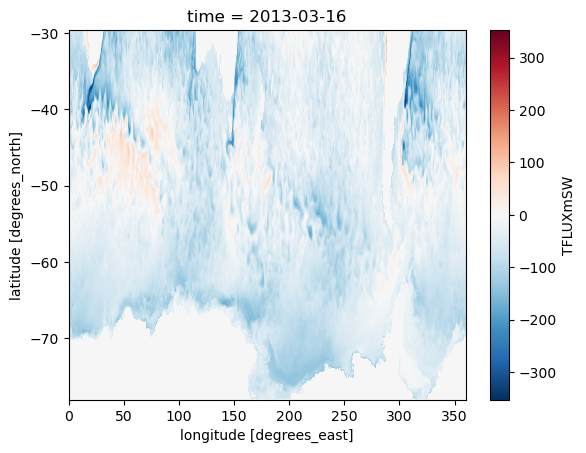

In [68]:
ds.TFLUXmSW.isel(time=0).plot()

In [69]:
ds=ds.transpose("time","time_bounds","Z","Zl","YC","YG","XC","XG")

In [80]:
nXG = np.size(ds.XG)
nYG = np.size(ds.YG)
nXC = np.size(ds.XC)
nYC = np.size(ds.YC)
nZ = np.size(ds.Z)

In [73]:
# Interfaces depth
Zi = -6000.0*np.ones(53)
Zi[:52] = ds.Zl.values
Zi

array([ 0.00000000e+00, -4.19999981e+00, -9.19999981e+00, -1.51000004e+01,
       -2.20000000e+01, -3.05000000e+01, -4.00000000e+01, -5.00000000e+01,
       -6.00000000e+01, -7.00000000e+01, -8.00000000e+01, -9.00000000e+01,
       -1.00000000e+02, -1.10000000e+02, -1.20000000e+02, -1.30000000e+02,
       -1.40000000e+02, -1.53000000e+02, -1.70000000e+02, -1.90000000e+02,
       -2.10000000e+02, -2.30000000e+02, -2.50000000e+02, -2.70000000e+02,
       -2.90000000e+02, -3.12000000e+02, -3.42000000e+02, -3.80000000e+02,
       -4.25000000e+02, -4.75000000e+02, -5.25000000e+02, -5.78000000e+02,
       -6.50000000e+02, -7.50000000e+02, -8.50000000e+02, -9.50000000e+02,
       -1.05000000e+03, -1.15000000e+03, -1.30000000e+03, -1.50000000e+03,
       -1.70000000e+03, -1.90000000e+03, -2.12000000e+03, -2.42000000e+03,
       -2.80000000e+03, -3.20000000e+03, -3.60000000e+03, -4.00000000e+03,
       -4.40000000e+03, -4.80000000e+03, -5.20000000e+03, -5.60000000e+03,
       -6.00000000e+03])

In [74]:
ds['Zi'] = xr.DataArray(data = Zi, 
                               dims = ['Zi'])

In [75]:
# We drop *VELMASS diags because we've already computed the mass transports
ds=ds.drop_vars(["UVELMASS","VVELMASS","WVELMASS"])

In [76]:
ds = ds.drop_vars(["Zl"])

In [82]:
geolon = np.zeros([nYC,nXC])
geolon[:,:] = np.reshape(ds.XC.values, [1,nXC])
geolon_c = np.zeros([nYG,nXG])
geolon_c[:,:] = np.reshape(ds.XG.values, [1,nXG])
geolon_u = np.zeros([nYC,nXG])
geolon_u[:,:] = np.reshape(ds.XG.values, [1,nXG])
geolon_v = np.zeros([nYG,nXC])
geolon_v[:,:] = np.reshape(ds.XC.values, [1,nXC])

geolat = np.zeros([nYC,nXC])
geolat[:,:] = np.reshape(ds.YC.values, [nYC,1])
geolat_c = np.zeros([nYG,nXG])
geolat_c[:,:] = np.reshape(ds.YG.values, [nYG,1])
geolat_u = np.zeros([nYC,nXG])
geolat_u[:,:] = np.reshape(ds.YC.values, [nYC,1])
geolat_v = np.zeros([nYG,nXC])
geolat_v[:,:] = np.reshape(ds.YG.values, [nYG,1])

In [83]:
ds['geolon'] = xr.DataArray(data = geolon, 
                               dims = ['YC','XC'],
                               coords = {'YC': ds['YC'],
                                         'XC': ds['XC']})
ds['geolat'] = xr.DataArray(data = geolat, 
                               dims = ['YC','XC'],
                               coords = {'YC': ds['YC'],
                                         'XC': ds['XC']})


ds['geolon_c'] = xr.DataArray(data = geolon_c, 
                               dims = ['YG','XG'],
                               coords = {'YG': ds['YG'],
                                         'XG': ds['XG']})
ds['geolat_c'] = xr.DataArray(data = geolat_c, 
                               dims = ['YG','XG'],
                               coords = {'YG': ds['YG'],
                                         'XG': ds['XG']})


ds['geolon_u'] = xr.DataArray(data = geolon_u, 
                               dims = ['YC','XG'],
                               coords = {'YC': ds['YC'],
                                         'XG': ds['XG']})
ds['geolat_u'] = xr.DataArray(data = geolat_u, 
                               dims = ['YC','XG'],
                               coords = {'YC': ds['YC'],
                                         'XG': ds['XG']})


ds['geolon_v'] = xr.DataArray(data = geolon_v, 
                               dims = ['YG','XC'],
                               coords = {'YG': ds['YG'],
                                         'XC': ds['XC']})
ds['geolat_v'] = xr.DataArray(data = geolat_v, 
                               dims = ['YG','XC'],
                               coords = {'YG': ds['YG'],
                                         'XC': ds['XC']})
ds = ds.set_coords(["geolon","geolon_c",
                            "geolon_u","geolon_v",
                            "geolat","geolat_c",
                            "geolat_u","geolat_v"])
ds["lat"] = ds["geolat"]
ds["lon"] = ds["geolon"]
ds = ds.set_coords(["lat","lon"])

In [ ]:
# switch to MOM6-like nomenclature
ds = ds.rename({"XC":"xh","YC":"yh","XG":"xq","YG":"yq"})

In [86]:
drC_bounds = np.zeros([2,nZ,nYC,nXC])
drC_bounds[:,:,:,:] = np.reshape(ds.drC.values, [1,nZ,nYC,nXC])
ds['drC_bounds'] = xr.DataArray(data = drC_bounds, 
                               dims = ['time_bounds','Z','yh','xh'],
                               coords = {'time_bounds': ds['time_bounds'],
                                         'Z': ds['Z'],
                                         'yh': ds['yh'],
                                         'xh': ds['xh']})

In [87]:
ds = ds.rename({"Z":"z_l","Zi":"z_i"})

In [88]:
ds["drC"]=ds.drC.expand_dims("time")

In [89]:
ds["SST"] = ds["THETA"].isel(z_l=0)
ds["SSS"] = ds["SALT"].isel(z_l=0)

In [90]:
ds

<xarray.Dataset> Size: 13GB
Dimensions:           (yh: 588, xq: 2160, z_l: 52, xh: 2160, yq: 588, time: 1,
                       time_bounds: 2, z_i: 53)
Coordinates: (12/48)
  * yh                (yh) float32 2kB -77.98 -77.95 -77.91 ... -29.87 -29.72
  * xq                (xq) float32 9kB 5.551e-17 0.1667 0.3333 ... 359.7 359.8
  * z_l               (z_l) float32 208B -2.1 -6.7 -12.15 ... -5.4e+03 -5.8e+03
    dyG               (yh, xq) float32 5MB ...
    dxC               (yh, xq) float32 5MB ...
    rAw               (yh, xq) float32 5MB ...
    ...                ...
    geolon_u          (yh, xq) float64 10MB 5.551e-17 0.1667 ... 359.7 359.8
    geolat_u          (yh, xq) float64 10MB -77.98 -77.98 ... -29.72 -29.72
    geolon_v          (yq, xh) float64 10MB 0.08333 0.25 0.4167 ... 359.8 359.9
    geolat_v          (yq, xh) float64 10MB -78.0 -78.0 -78.0 ... -29.8 -29.8
    lat               (yh, xh) float64 10MB -77.98 -77.98 ... -29.72 -29.72
    lon               (yh, xh) float64 10MB 0.08333 0.25 0.4167 ... 359.8 359.9
Data variables: (12/35)
    oceFWflx          (time, yh, xh) float32 5MB ...
    THETA             (time, z_l, yh, xh) float32 264MB ...
    SALT              (time, z_l, yh, xh) float32 264MB ...
    SFLUX             (time, yh, xh) float32 5MB ...
    SSH_bounds        (time_bounds, yh, xh) float32 10MB 0.0 0.0 ... 0.03582
    THETA_bounds      (time_bounds, z_l, yh, xh) float32 528MB ...
    ...                ...
    sigma2_bounds     (time_bounds, z_l, yh, xh) float64 1GB 9.785 ... 9.785
    mask2D            (yh, xh) float64 10MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0
    land              (yh, xh) bool 1MB True True True ... False False False
    drC_bounds        (time_bounds, z_l, yh, xh) float64 1GB 0.0 0.0 ... 0.0 0.0
    SST               (time, yh, xh) float32 5MB ...
    SSS               (time, yh, xh) float32 5MB ...

In [91]:
ds["maskZ"] = xr.DataArray(np.zeros(len(ds['z_l'])),dims=['z_l'],coords={'z_l':ds['z_l']})
ds["maskZ"][0] = 1 
ds = ds.set_coords("maskZ")

In [95]:
# 3D broadcast of surface 2D diagnostics
ds["oceFWflx"]=ds["oceFWflx"]*ds.maskZ
ds["TFLUXmSW"] = ds["TFLUXmSW"]*ds.maskZ
ds["SFLUX"] = ds["SFLUX"]*ds.maskZ

In [96]:
# Grouping zonal and meridional compoments into "horizontal" to reduce dataset size
ds["DELTA_ADVh_TH"] = ds["DELTA_ADVx_TH"] + ds["DELTA_ADVy_TH"]
ds["DELTA_DFhE_TH"] = ds["DELTA_DFxE_TH"] + ds["DELTA_DFyE_TH"]
ds["DELTA_ADVh_SLT"] = ds["DELTA_ADVx_SLT"] + ds["DELTA_ADVy_SLT"]
ds["DELTA_DFhE_SLT"] = ds["DELTA_DFxE_SLT"] + ds["DELTA_DFyE_SLT"]

In [97]:
ds=ds.drop_vars(["DELTA_ADVx_TH","DELTA_ADVy_TH",
                         "DELTA_DFxE_TH","DELTA_DFyE_TH",
                         "DELTA_ADVx_SLT","DELTA_ADVy_SLT",
                         "DELTA_DFxE_SLT","DELTA_DFyE_SLT"])

In [98]:
ds = ds.set_coords(["depthC","mask2D","land"])

In [99]:
ds=ds.transpose("time","time_bounds","z_l","z_i","yh","yq","xh","xq")
ds

<xarray.Dataset> Size: 13GB
Dimensions:           (yh: 588, xq: 2160, z_l: 52, xh: 2160, yq: 588, time: 1,
                       time_bounds: 2, z_i: 53)
Coordinates: (12/52)
  * yh                (yh) float32 2kB -77.98 -77.95 -77.91 ... -29.87 -29.72
  * xq                (xq) float32 9kB 5.551e-17 0.1667 0.3333 ... 359.7 359.8
  * z_l               (z_l) float32 208B -2.1 -6.7 -12.15 ... -5.4e+03 -5.8e+03
    dyG               (yh, xq) float32 5MB ...
    dxC               (yh, xq) float32 5MB ...
    rAw               (yh, xq) float32 5MB ...
    ...                ...
    geolat_u          (yh, xq) float64 10MB -77.98 -77.98 ... -29.72 -29.72
    geolon_v          (yq, xh) float64 10MB 0.08333 0.25 0.4167 ... 359.8 359.9
    geolat_v          (yq, xh) float64 10MB -78.0 -78.0 -78.0 ... -29.8 -29.8
    lat               (yh, xh) float64 10MB -77.98 -77.98 ... -29.72 -29.72
    lon               (yh, xh) float64 10MB 0.08333 0.25 0.4167 ... 359.8 359.9
    maskZ             (z_l) float64 416B 1.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Data variables: (12/28)
    oceFWflx          (time, z_l, yh, xh) float64 528MB 0.0 0.0 ... -0.0 -0.0
    THETA             (time, z_l, yh, xh) float32 264MB ...
    SALT              (time, z_l, yh, xh) float32 264MB ...
    SFLUX             (time, z_l, yh, xh) float64 528MB 0.0 0.0 0.0 ... 0.0 0.0
    SSH_bounds        (time_bounds, yh, xh) float32 10MB 0.0 0.0 ... 0.03582
    THETA_bounds      (time_bounds, z_l, yh, xh) float32 528MB ...
    ...                ...
    SST               (time, yh, xh) float32 5MB ...
    SSS               (time, yh, xh) float32 5MB ...
    DELTA_ADVh_TH     (time, z_l, yh, xh) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0
    DELTA_DFhE_TH     (time, z_l, yh, xh) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0
    DELTA_ADVh_SLT    (time, z_l, yh, xh) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0
    DELTA_DFhE_SLT    (time, z_l, yh, xh) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0

In [101]:
ds.oceFWflx.attrs['long_name'] = "Net fresh water flux into ocean at sea surface"
ds.oceFWflx.attrs['units'] = "kg s-1 m-2"

ds.THETA.attrs['long_name'] = "Potential temperature"
ds.THETA.attrs['units'] = "degC"

ds.SALT.attrs['long_name'] = "Salinity"
ds.SALT.attrs['units'] = "g kg-1"

ds.SFLUX.attrs['long_name'] = "Net salt flux into ocean at sea surface"
ds.SFLUX.attrs['units'] = "g m-2 s-1"

ds.UMASSTRANS.attrs['long_name'] = "Zonal mass transport"
ds.UMASSTRANS.attrs['units'] = "kg s-1"

ds.VMASSTRANS.attrs['long_name'] = "Meridional mass transport"
ds.VMASSTRANS.attrs['units'] = "kg s-1"

ds.DELTA_WMASSTRANS.attrs['long_name'] = "Vertical mass transport convergence"
ds.DELTA_WMASSTRANS.attrs['units'] = "kg s-1"

ds.SSH_TEND_3D.attrs['long_name'] = "Thickness tendency due to Z* stretching"
ds.SSH_TEND_3D.attrs['units'] = "m s-1"

ds.TEMP_TEND.attrs['long_name'] = "Total potential temperature tendency"
ds.TEMP_TEND.attrs['units'] = "degC s-1"

ds.SALIN_TEND.attrs['long_name'] = "Total salinity tendency"
ds.SALIN_TEND.attrs['units'] = "g kg-1 s-1"

ds.DELTA_ADVh_TH.attrs['long_name'] = "Pot. temp. advective tendency (horizontal)"
ds.DELTA_ADVh_TH.attrs['units'] = "degC m3 s-1"

ds.DELTA_ADVr_TH.attrs['long_name'] = "Pot. temp. advective tendency (vertical)"
ds.DELTA_ADVr_TH.attrs['units'] = "degC m3 s-1"

ds.DELTA_DFhE_TH.attrs['long_name'] = "Pot. temp. diffusive tendency (horizontal)"
ds.DELTA_DFhE_TH.attrs['units'] = "degC m3 s-1"

ds.DELTA_DFrI_TH.attrs['long_name'] = "Pot. temp. diffusive tendency (vertical)"
ds.DELTA_DFrI_TH.attrs['units'] = "degC m3 s-1"

ds.DELTA_ADVh_SLT.attrs['long_name'] = "Salinity advective tendency (horizontal)"
ds.DELTA_ADVh_SLT.attrs['units'] = "g kg-1 m3 s-1"

ds.DELTA_ADVr_SLT.attrs['long_name'] = "Salinity advective tendency (vertical)"
ds.DELTA_ADVr_SLT.attrs['units'] = "g kg-1 m3 s-1"

ds.DELTA_DFhE_SLT.attrs['long_name'] = "Salinity diffusive tendency (horizontal)"
ds.DELTA_DFhE_SLT.attrs['units'] = "g kg-1 m3 s-1"

ds.DELTA_DFrI_SLT.attrs['long_name'] = "Salinity diffusive tendency (vertical)"
ds.DELTA_DFrI_SLT.attrs['units'] = "g kg-1 m3 s-1"

ds.TFLUXmSW.attrs['long_name'] = "Net heat flux into ocean (excl. short wave)"
ds.TFLUXmSW.attrs['units'] = "W m-2"

ds.SBSFQSW.attrs['long_name'] = "Short wave heat flux convergence"
ds.SBSFQSW.attrs['units'] = "W m-2"

ds.SST.attrs['long_name'] = "Sea surface temperature"
ds.SST.attrs['units'] = "degC"

ds.SSS.attrs['long_name'] = "Sea surface salinity"
ds.SSS.attrs['units'] = "g kg-1"

ds.sigma2.attrs['long_name'] = "Potential density (referenced to 2000dB)"
ds.sigma2.attrs['units'] = "kg m-3"

ds.sigma2_bounds.attrs['long_name'] = "Potential density bounds (referenced to 2000dB)"
ds.sigma2_bounds.attrs['units'] = "kg m-3"
del ds.sigma2_bounds.attrs['standard_name']

ds.drC_bounds.attrs['long_name'] = "Cell thickness bounds"
ds.drC_bounds.attrs['units'] = "m"

ds.SSH_bounds.attrs['long_name'] = "Surface Height Anomaly bounds"
del ds.SSH_bounds.attrs['standard_name']

In [102]:
ds

<xarray.Dataset> Size: 13GB
Dimensions:           (yh: 588, xq: 2160, z_l: 52, xh: 2160, yq: 588, time: 1,
                       time_bounds: 2, z_i: 53)
Coordinates: (12/52)
  * yh                (yh) float32 2kB -77.98 -77.95 -77.91 ... -29.87 -29.72
  * xq                (xq) float32 9kB 5.551e-17 0.1667 0.3333 ... 359.7 359.8
  * z_l               (z_l) float32 208B -2.1 -6.7 -12.15 ... -5.4e+03 -5.8e+03
    dyG               (yh, xq) float32 5MB ...
    dxC               (yh, xq) float32 5MB ...
    rAw               (yh, xq) float32 5MB ...
    ...                ...
    geolat_u          (yh, xq) float64 10MB -77.98 -77.98 ... -29.72 -29.72
    geolon_v          (yq, xh) float64 10MB 0.08333 0.25 0.4167 ... 359.8 359.9
    geolat_v          (yq, xh) float64 10MB -78.0 -78.0 -78.0 ... -29.8 -29.8
    lat               (yh, xh) float64 10MB -77.98 -77.98 ... -29.72 -29.72
    lon               (yh, xh) float64 10MB 0.08333 0.25 0.4167 ... 359.8 359.9
    maskZ             (z_l) float64 416B 1.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Data variables: (12/28)
    oceFWflx          (time, z_l, yh, xh) float64 528MB 0.0 0.0 ... -0.0 -0.0
    THETA             (time, z_l, yh, xh) float32 264MB ...
    SALT              (time, z_l, yh, xh) float32 264MB ...
    SFLUX             (time, z_l, yh, xh) float64 528MB 0.0 0.0 0.0 ... 0.0 0.0
    SSH_bounds        (time_bounds, yh, xh) float32 10MB 0.0 0.0 ... 0.03582
    THETA_bounds      (time_bounds, z_l, yh, xh) float32 528MB ...
    ...                ...
    SST               (time, yh, xh) float32 5MB ...
    SSS               (time, yh, xh) float32 5MB ...
    DELTA_ADVh_TH     (time, z_l, yh, xh) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0
    DELTA_DFhE_TH     (time, z_l, yh, xh) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0
    DELTA_ADVh_SLT    (time, z_l, yh, xh) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0
    DELTA_DFhE_SLT    (time, z_l, yh, xh) float32 264MB 0.0 0.0 0.0 ... 0.0 0.0

In [103]:
#ds.to_netcdf("./SOSE_xWMB_data_Weddell_march_2013.nc")
#ds = xr.open_dataset("./SOSE_xWMB_data_Weddell_march_2013.nc")